In [1]:
import requests
import pandas as pd
from io import StringIO

# 1. Base API endpoint
url = (
    "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/"
    "dataflow/ESTAT/ISOC_EB_AI/1.0"
)

# 2. Filters sent with the request
params = {
    "format": "csvdata",
    "formatVersion": "2.0",
    "compress": "false"

}

# 3. Send GET request
response = requests.get(url, params=params)

# 4. Check whether it worked
print(response.status_code)

# 5. Turn returned CSV text into a DataFrame
ai_adoption_df = pd.read_csv(StringIO(response.text))

# 6. Inspect the result
ai_adoption_df.head()

200


,STRUCTURE,STRUCTURE_ID,freq,size_emp,nace_r2,indic_is,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2023,5.74,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2024,5.66,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2025,5.49,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,PT,2023,13.36,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT_IUSE,ES,2023,6.88,NaN,NaN


In [2]:
ai_adoption_df

,STRUCTURE,STRUCTURE_ID,freq,size_emp,nace_r2,indic_is,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2023,5.74,NaN,NaN
1,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2024,5.66,NaN,NaN
2,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,ES,2025,5.49,NaN,NaN
3,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT,PT,2023,13.36,NaN,NaN
4,dataflow,ESTAT:ISOC_EB_AI(1.0),A,0-9,C10-S951_X_K,E_AIX_CC1SIX_DA,PC_ENT_IUSE,ES,2023,6.88,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
72522,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SI,2023,0.00,NaN,NaN
72523,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SI,2025,0.00,NaN,NaN
72524,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SK,2023,0.18,NaN,NaN
72525,dataflow,ESTAT:ISOC_EB_AI(1.0),A,GE250,C10-S951_X_K,E_DI3_VLO_AI_TANY,PC_ENT,SK,2025,1.11,NaN,NaN


In [3]:
ai_adoption_df_clean=ai_adoption_df.copy()

In [4]:
ai_adoption_df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'freq', 'size_emp', 'nace_r2', 'indic_is',
       'unit', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS'],
      dtype='object')

In [5]:
ai_adoption_df.shape


(72527, 12)

In [6]:
ai_adoption_df_clean.columns = (
    ai_adoption_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [7]:
ai_adoption_df_clean.columns

Index(['structure', 'structure_id', 'freq', 'size_emp', 'nace_r2', 'indic_is',
       'unit', 'geo', 'time_period', 'obs_value', 'obs_flag', 'conf_status'],
      dtype='object')

In [8]:
ai_adoption_df_clean_dropped = ai_adoption_df_clean.drop(
    columns=["structure", "structure_id"]
)

In [9]:
columns_to_check = [
    "freq",
    "size_emp",
    "nace_r2",
    "indic_is",
    "unit"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(ai_adoption_df_clean_dropped[column].value_counts())


--- freq ---
freq
A    72527
Name: count, dtype: int64

--- size_emp ---
size_emp
10-249    13988
50-249    13988
GE10      13988
GE250     13987
10-49     13979
2-9        1286
0-9         912
0_1         399
Name: count, dtype: int64

--- nace_r2 ---
nace_r2
C10-S951_X_K    72527
Name: count, dtype: int64

--- indic_is ---
indic_is
E_AI_PITS          2146
E_AI_PPP           2146
E_AI_PMS           2146
E_AI_PLOG          2146
E_AI_BDDT          1983
                   ... 
E_AI_BIAS_ARDY      212
E_AI_BIAS_AMOWN     209
E_AI_BIAS_AOS       209
E_AI_BIAS_ADOWN     209
E_AI_PDI            142
Name: count, Length: 63, dtype: int64

--- unit ---
unit
PC_ENT            28062
PC_ENT_IUSE       26185
PC_ENT_AI_TANY     9464
PC_ENT_AI_TX       4454
PC_ENT_AI_EC       3945
PC_ENT_AI_PDI       417
Name: count, dtype: int64


In [10]:
ai_adoption_df_clean_dropped[
    ai_adoption_df_clean_dropped["indic_is"] == "E_AI_TANY"
][["size_emp", "unit"]].value_counts()

size_emp  unit       
10-49     PC_ENT_IUSE    140
          PC_ENT         140
10-249    PC_ENT_IUSE    140
          PC_ENT         140
GE10      PC_ENT         140
          PC_ENT_IUSE    140
50-249    PC_ENT         140
          PC_ENT_IUSE    140
GE250     PC_ENT         140
          PC_ENT_IUSE    140
2-9       PC_ENT          12
          PC_ENT_IUSE     12
0-9       PC_ENT           9
          PC_ENT_IUSE      9
0_1       PC_ENT           5
          PC_ENT_IUSE      5
Name: count, dtype: int64

In [11]:
ai_adoption_project = ai_adoption_df_clean_dropped[
    (ai_adoption_df_clean_dropped["size_emp"] == "GE10")
    & (ai_adoption_df_clean_dropped["indic_is"] == "E_AI_TANY")
    & (ai_adoption_df_clean_dropped["unit"] == "PC_ENT")
].copy()

In [12]:
ai_adoption_final = ai_adoption_project[
    ["geo", "time_period", "obs_value"]
].rename(
    columns={
        "geo": "country_code",
        "time_period": "year",
        "obs_value": "ai_adoption_pct"
    }
)

In [13]:
ai_adoption_final

,country_code,year,ai_adoption_pct
55148,AL,2021,3.67
55149,AL,2024,8.91
55150,AL,2025,8.99
55151,AT,2021,8.83
55152,AT,2023,10.79
...,...,...,...
55283,SK,2025,18.00
55284,TR,2021,2.69
55285,TR,2023,5.51
55286,TR,2024,4.42


In [14]:
ai_adoption_final.groupby("country_code")["ai_adoption_pct"].mean()

country_code
AL            7.1900
AT           17.4600
BA            6.1375
BE           20.8450
BG            5.4825
CY            6.1075
CZ            9.8050
DE           16.9575
DK           27.1675
EA           13.2400
EE           11.3125
EL            6.3325
ES           12.1075
EU27_2020    12.2850
FI           23.2700
FR           10.1550
HR           10.8950
HU            6.1100
IE           12.6075
IT            8.9550
LT            9.8425
LU           21.1975
LV            7.3225
ME            6.7275
MK               NaN
MT           15.5350
NL           20.8675
NO           17.4125
PL            5.1975
PT            8.8075
RO            2.7925
RS            4.9475
SE           20.1050
SI           16.4000
SK           10.2525
TR            5.0075
Name: ai_adoption_pct, dtype: float64

In [15]:
ai_adoption_by_year = (
    ai_adoption_final
    .groupby(["country_code", "year"])["ai_adoption_pct"]
    .mean()
    .reset_index()
)

In [16]:
exclude_codes = ["EA", "EU27_2020"]

ai_adoption_countries = ai_adoption_final[
    ~ai_adoption_final["country_code"].isin(exclude_codes)
].copy()

In [17]:
ai_adoption_by_year["country_code"].unique()

array(['AL', 'AT', 'BA', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EA', 'EE',
       'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT',
       'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS',
       'SE', 'SI', 'SK', 'TR'], dtype=object)

In [170]:
ai_2025 = ai_adoption_countries[
    ai_adoption_countries["year"] == 2025
].sort_values("ai_adoption_pct", ascending=False)

In [19]:
country_names = {
    "AL": "Albania",
    "AT": "Austria",
    "BA": "Bosnia and Herzegovina",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CY": "Cyprus",
    "CZ": "Czechia",
    "DE": "Germany",
    "DK": "Denmark",
    "EE": "Estonia",
    "EL": "Greece",
    "ES": "Spain",
    "FI": "Finland",
    "FR": "France",
    "HR": "Croatia",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "LV": "Latvia",
    "ME": "Montenegro",
    "MK": "North Macedonia",
    "MT": "Malta",
    "NL": "Netherlands",
    "NO": "Norway",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "RS": "Serbia",
    "SE": "Sweden",
    "SI": "Slovenia",
    "SK": "Slovakia",
    "TR": "Türkiye"
}

# Chart Summary
Enterprise AI adoption in 2025 varies substantially across the countries shown. Nordic and several Western European countries lead the ranking, indicating that AI use is already relatively well established among businesses in these markets. Adoption is lower across much of Southern, Central, and Eastern Europe, showing that enterprise AI growth is not occurring at the same pace across the region.

This uneven pattern supports the wider project finding that AI sustainability cannot be assessed with a single European average. Countries are adopting AI under very different economic, digital-infrastructure, and energy-system conditions, so the environmental implications of future AI growth are likely to differ by country.

In [172]:
ai_adoption_by_year["year"].value_counts()

year
2021    36
2024    35
2025    35
2023    34
Name: count, dtype: int64

In [ ]:
ai_adoption_project

,freq,size_emp,nace_r2,indic_is,unit,geo,time_period,obs_value,obs_flag,conf_status
55148,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2021,3.67,NaN,NaN
55149,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2024,8.91,NaN,NaN
55150,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AL,2025,8.99,NaN,NaN
55151,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AT,2021,8.83,NaN,NaN
55152,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,AT,2023,10.79,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
55283,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,SK,2025,18.00,NaN,NaN
55284,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2021,2.69,NaN,NaN
55285,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2023,5.51,NaN,NaN
55286,A,GE10,C10-S951_X_K,E_AI_TANY,PC_ENT,TR,2024,4.42,NaN,NaN


In [ ]:
ai_adoption_final["ai_adoption_pct"].isnull().sum()

np.int64(1)

In [ ]:
ai_adoption_final = ai_adoption_final.dropna(
    subset=["ai_adoption_pct"])

In [ ]:
ai_adoption_final

,country_code,year,ai_adoption_pct
55148,AL,2021,3.67
55149,AL,2024,8.91
55150,AL,2025,8.99
55151,AT,2021,8.83
55152,AT,2023,10.79
...,...,...,...
55283,SK,2025,18.00
55284,TR,2021,2.69
55285,TR,2023,5.51
55286,TR,2024,4.42


# Day 3 EDA

In [58]:
# Load the dataset
import pandas as pd

# Load datasets
emissions = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/clean_eurostat_power_sector_emissions.csv?raw=true"
)

ai_adoption = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/ai_adoption_cleaned.csv?raw=true"
)

renewable = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/cleaned_renewable_energy.csv?raw=true"
)

datacenter = pd.read_csv(
    "https://github.com/Orgo4ever/data-wrangling-project/blob/main/eu_facilities_cleaned.csv?raw=true"
)

# Make sure geo and year have matching formats
for df in [emissions_subset, renewable_subset, ai_subset]:
    df["geo"] = df["geo"].astype(str).str.strip().str.upper()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Keep one row per country-year in each dataset
emissions_subset = (
    emissions_subset
    .groupby(["geo", "year"], as_index=False)["emissions"]
    .mean()
)

renewable_subset = (
    renewable_subset
    .groupby(["geo", "year"], as_index=False)["renewable_energy_share"]
    .mean()
)

ai_subset = (
    ai_subset
    .groupby(["geo", "year"], as_index=False)["ai_adoption_pct"]
    .mean()
)

# Start with AI adoption so all AI years, including 2025, are kept
grouped_df = (
    ai_subset
    .merge(
        renewable_subset,
        on=["geo", "year"],
        how="left"
    )
    .merge(
        emissions_subset,
        on=["geo", "year"],
        how="left"
    )
)

# Add country names
grouped_df["country_name"] = grouped_df["geo"].map(country_names)

# Sort and reset index
grouped_df = (
    grouped_df
    .sort_values(["geo", "year"])
    .reset_index(drop=True)
)

# Check whether 2025 is included
print("Latest year in AI dataset:", ai_subset["year"].max())
print("Latest year in grouped dataframe:", grouped_df["year"].max())

print(grouped_df.tail())

Latest year in AI dataset: 2025
Latest year in grouped dataframe: 2025
    geo  year  ai_adoption_pct  renewable_energy_share     emissions  \
126  SK  2025            18.00                     NaN           NaN   
127  TR  2021             2.69                     NaN  79097.198180   
128  TR  2023             5.51                     NaN  76613.496960   
129  TR  2024             4.42                     NaN  80135.840785   
130  TR  2025             7.41                     NaN           NaN   

    country_name  
126     Slovakia  
127      Türkiye  
128      Türkiye  
129      Türkiye  
130      Türkiye  


In [60]:
# Select relevant columns
emissions_subset = emissions[["geo", "year", "emissions"]].copy()

renewable_subset = renewable[[
    "geo",
    "year",
    "renewable_energy_share"
]].copy()

ai_subset = ai_adoption[[
    "country_code",
    "year",
    "ai_adoption_pct"
]].rename(columns={"country_code": "geo"}).copy()

# Make country codes and years consistent before merging
for df in [emissions_subset, renewable_subset, ai_subset]:
    df["geo"] = (
        df["geo"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Make sure there is only one row per country per year
emissions_subset = (
    emissions_subset
    .groupby(["geo", "year"], as_index=False)["emissions"]
    .mean()
)

renewable_subset = (
    renewable_subset
    .groupby(["geo", "year"], as_index=False)["renewable_energy_share"]
    .mean()
)

ai_subset = (
    ai_subset
    .groupby(["geo", "year"], as_index=False)["ai_adoption_pct"]
    .mean()
)

# Start with AI adoption so its years, including 2025, are preserved
grouped_df = (
    ai_subset
    .merge(
        renewable_subset,
        on=["geo", "year"],
        how="left"
    )
    .merge(
        emissions_subset,
        on=["geo", "year"],
        how="left"
    )
)

# Add full country names if country_names dictionary already exists
grouped_df["country_name"] = grouped_df["geo"].map(country_names)

# Sort the finished dataframe
grouped_df = (
    grouped_df
    .sort_values(["geo", "year"])
    .reset_index(drop=True)
)



In [61]:
grouped_df["year"].unique()

array([2021, 2024, 2025, 2023])

In [25]:
import pandas as pd

ai_clean = (
    ai_adoption
    .groupby(["country_code", "year"], as_index=False)
    .agg({"ai_adoption_pct": "mean"})
    .rename(columns={"country_code": "geo"})
)

latest_year = ai_clean["year"].max()

top10 = (
    ai_clean[ai_clean["year"] == latest_year]
    .sort_values("ai_adoption_pct", ascending=False)
    .head(10)
)

print(top10)

    geo  year  ai_adoption_pct
34   DK  2025            42.03
50   FI  2025            37.82
118  SE  2025            35.04
14   BE  2025            34.54
78   LU  2025            33.61
94   NL  2025            33.21
6    AT  2025            29.95
98   NO  2025            28.89
30   DE  2025            25.97
38   EE  2025            23.40


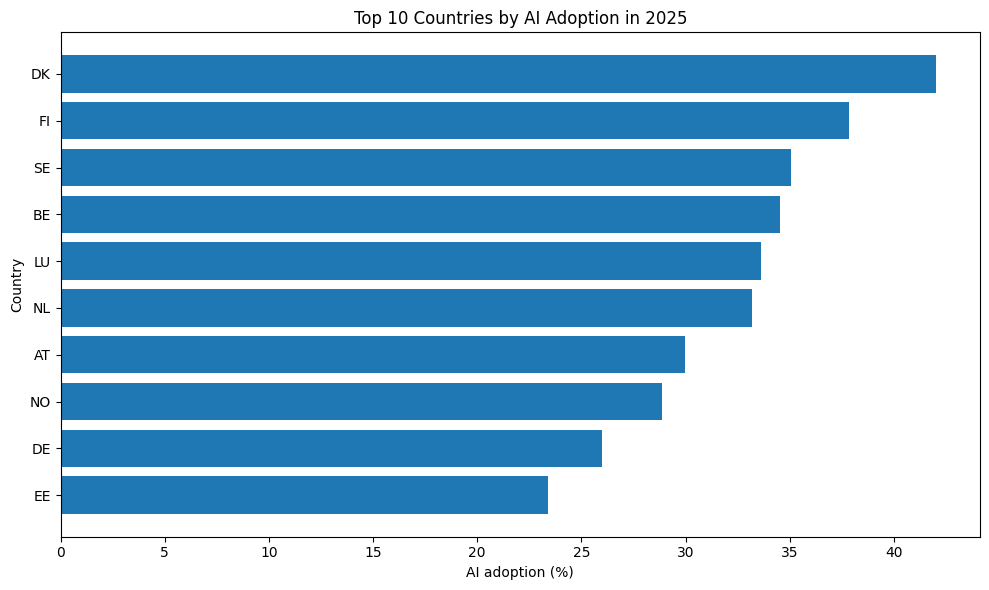

In [173]:
import matplotlib.pyplot as plt

# Sort so the highest-adoption country appears at the top
top10_plot = top10.sort_values("ai_adoption_pct", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_plot["geo"],
    top10_plot["ai_adoption_pct"]
)

plt.title(f"Top 10 Countries by AI Adoption in {latest_year}")
plt.xlabel("AI adoption (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("ai_adoption_2024_top10.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart Summary
The top 10 ranking shows that enterprise AI adoption is led primarily by Nordic and Western European countries, with Denmark standing out as the strongest adopter. The leading group includes countries with well-developed digital economies, while the presence of Estonia also shows that smaller, digitally advanced countries can achieve high business AI uptake.

For the wider project, these countries represent the areas where AI-related demand and supporting digital infrastructure may grow most quickly. However, high adoption alone does not determine sustainability: the environmental implications depend on whether each country’s energy system and data-centre infrastructure are supported by a strong renewable-energy base.

In [92]:
ai_adoption_trend = (
    ai_adoption_countries
    .groupby("year", as_index=False)
    .agg(
        average_ai_adoption_pct=("ai_adoption_pct", "mean"),
        countries_reporting=("ai_adoption_pct", "count")
    )
    .sort_values("year")
)

ai_adoption_trend

,year,average_ai_adoption_pct,countries_reporting
0,2021,7.012727,33
1,2023,7.807812,32
2,2024,13.359394,33
3,2025,19.270606,33


In [63]:
facilities_by_country = (
    datacenter
    .groupby("geo")
    .size()
    .reset_index(name="facility_count")
)

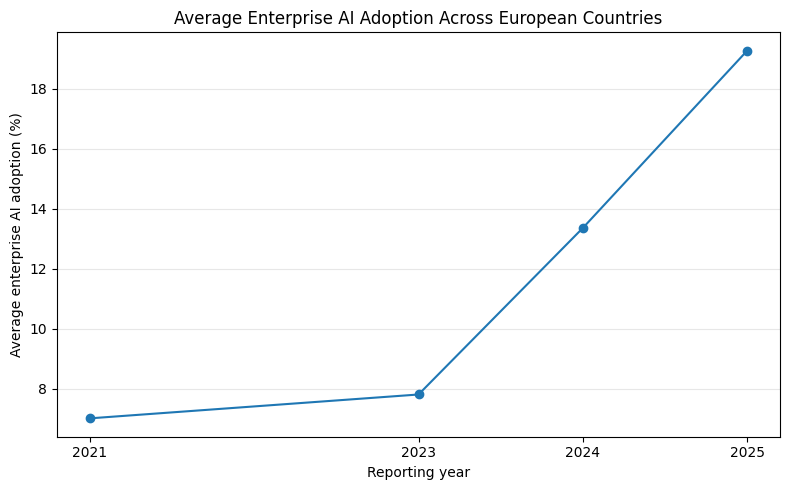

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    ai_adoption_trend["year"],
    ai_adoption_trend["average_ai_adoption_pct"],
    marker="o"
)

plt.xlabel("Reporting year")
plt.ylabel("Average enterprise AI adoption (%)")
plt.title("Average Enterprise AI Adoption Across European Countries")

plt.xticks(ai_adoption_trend["year"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ai_adoption_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart Summary
Average enterprise AI adoption increased substantially across the countries in the dataset, with relatively limited growth between 2021 and 2023 followed by a much sharper rise in 2024 and 2025. This suggests that business use of AI is moving from early adoption toward more widespread implementation across Europe.

The chart supports the project’s central question because a faster expansion of enterprise AI could increase demand for digital infrastructure and electricity. However, the line should be interpreted carefully: 2022 is not available in the dataset, so it shows reported observation years rather than a fully continuous annual trend.

In [73]:
# Remove any facility-count columns from earlier attempts
grouped_df = grouped_df.drop(
    columns=["facility_count", "facility_count_x", "facility_count_y"],
    errors="ignore"
).copy()

# Ensure geo codes match
grouped_df["geo"] = (
    grouped_df["geo"]
    .astype("string")
    .str.strip()
    .str.upper()
)

datacenter["geo"] = (
    datacenter["geo"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# One facility count per country
facilities_by_country = (
    datacenter
    .dropna(subset=["geo"])
    .groupby("geo", as_index=False)
    .size()
    .rename(columns={"size": "facility_count"})
)

# This confirms there is only one row per geo in the facilities table
print("Duplicate countries in facilities table:",
      facilities_by_country["geo"].duplicated().sum())

# Merge: many country-year rows in grouped_df -> one country row in facilities_by_country
grouped_df = grouped_df.merge(
    facilities_by_country,
    on="geo",
    how="left",
    validate="m:1"
)

grouped_df["datacenters"] = (
    grouped_df["facility_count"]
    .fillna(0)
    .astype(int)
)

print(grouped_df.head())

Duplicate countries in facilities table: 0
  geo  year  ai_adoption_pct  renewable_energy_share    emissions  \
0  AL  2021             3.67                  41.389          NaN   
1  AL  2024             8.91                  43.111          NaN   
2  AL  2025             8.99                     NaN          NaN   
3  AT  2021             8.83                  34.643  4289.129845   
4  AT  2023            10.79                  41.600  3595.912320   

  country_name  datacenters  facility_count  
0      Albania            0             NaN  
1      Albania            0             NaN  
2      Albania            0             NaN  
3      Austria           56            56.0  
4      Austria           56            56.0  


In [74]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters,facility_count
0,AL,2021,3.67,41.389,NaN,Albania,0,NaN
1,AL,2024,8.91,43.111,NaN,Albania,0,NaN
2,AL,2025,8.99,NaN,NaN,Albania,0,NaN
3,AT,2021,8.83,34.643,4289.129845,Austria,56,56.0
4,AT,2023,10.79,41.600,3595.912320,Austria,56,56.0
...,...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6,6.0
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0,NaN
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0,NaN
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0,NaN


In [43]:
grouped_df

,geo,year,emissions,renewable_energy_share,ai_adoption_pct,facility_count
0,AT,2015,10.33398,33.497,NaN,56
1,AT,2016,10.11920,33.370,NaN,56
2,AT,2017,10.73059,33.136,NaN,56
3,AT,2018,9.88490,33.784,NaN,56
4,AT,2019,9.92108,33.755,NaN,56
...,...,...,...,...,...,...
635,TR,2020,141054.20000,NaN,NaN,0
636,TR,2021,158036.36000,NaN,2.69,0
637,TR,2022,154784.03000,NaN,NaN,0
638,TR,2023,153073.92000,NaN,5.51,0


In [75]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters,facility_count
0,AL,2021,3.67,41.389,NaN,Albania,0,NaN
1,AL,2024,8.91,43.111,NaN,Albania,0,NaN
2,AL,2025,8.99,NaN,NaN,Albania,0,NaN
3,AT,2021,8.83,34.643,4289.129845,Austria,56,56.0
4,AT,2023,10.79,41.600,3595.912320,Austria,56,56.0
...,...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6,6.0
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0,NaN
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0,NaN
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0,NaN


In [77]:
grouped_df.columns

Index(['geo', 'year', 'ai_adoption_pct', 'renewable_energy_share', 'emissions',
       'country_name', 'datacenters', 'facility_count'],
      dtype='object')

In [78]:
grouped_df = grouped_df.drop(columns="facility_count")

In [79]:
grouped_df

,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters
0,AL,2021,3.67,41.389,NaN,Albania,0
1,AL,2024,8.91,43.111,NaN,Albania,0
2,AL,2025,8.99,NaN,NaN,Albania,0
3,AT,2021,8.83,34.643,4289.129845,Austria,56
4,AT,2023,10.79,41.600,3595.912320,Austria,56
...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0


In [80]:
grouped_df.to_csv("merged_data.csv", index=False)

# Part 3 

In [96]:
ai_df = pd.read_csv("ai_adoption_cleaned.csv")
renewable_df = pd.read_csv("cleaned_renewable_energy.csv")

In [97]:
excluded_codes = ["EA", "EA20", "EA21", "EU27_2020"]

ai_2024 = ai_df[
    (ai_df["year"] == 2024)
    & (~ai_df["country_code"].isin(excluded_codes))
][["country_code", "ai_adoption_pct"]].copy()

renewable_2024 = renewable_df[
    (renewable_df["year"] == 2024)
    & (~renewable_df["geo"].isin(excluded_codes))
][["geo", "country", "renewable_energy_share"]].copy()

renewable_2024 = renewable_2024.rename(
    columns={"geo": "country_code"}
)

In [98]:
part3_df = ai_2024.merge(
    renewable_2024,
    on="country_code",
    how="inner",
    validate="one_to_one"
)

part3_df.head()

,country_code,ai_adoption_pct,country,renewable_energy_share
0,AL,8.91,Albania,43.111
1,AT,20.27,Austria,42.951
2,BA,6.36,Bosnia and Herzegovina,38.524
3,BE,24.71,Belgium,14.336
4,BG,6.47,Bulgaria,23.210


In [99]:
print("Countries included:", part3_df["country_code"].nunique())
print("Duplicate country rows:", part3_df["country_code"].duplicated().sum())

Countries included: 32
Duplicate country rows: 0


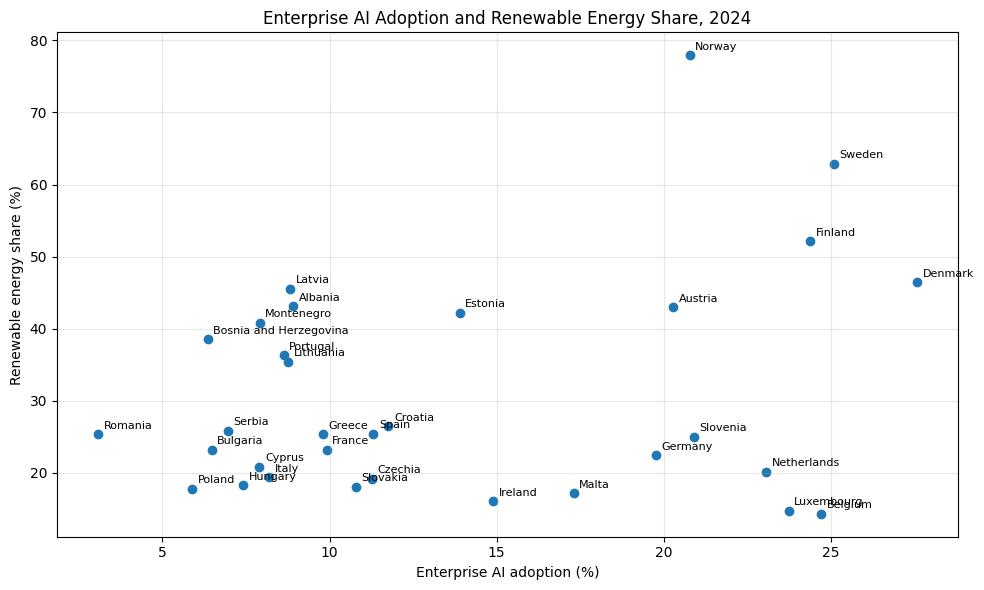

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    part3_df["ai_adoption_pct"],
    part3_df["renewable_energy_share"]
)

for _, row in part3_df.iterrows():
    plt.annotate(
        row["country"],
        (row["ai_adoption_pct"], row["renewable_energy_share"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Enterprise AI adoption (%)")
plt.ylabel("Renewable energy share (%)")
plt.title("Enterprise AI Adoption and Renewable Energy Share, 2024")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart Summary
The chart suggests a modest positive relationship between enterprise AI adoption and renewable-energy share, but not a simple one-to-one pattern. Several countries with high AI adoption also have strong renewable-energy systems, indicating comparatively favourable conditions for supporting AI growth. However, other high-adoption countries have much lower renewable shares, showing that advanced business AI use does not automatically mean it is supported by a cleaner energy base.

Overall, AI expansion is occurring across very different national energy contexts. This means the sustainability of future AI growth is likely to depend less on adoption alone and more on whether each country’s energy system can support growing digital demand with renewable sources.

In [105]:
ai_renewable_corr = part3_df["ai_adoption_pct"].corr(
    part3_df["renewable_energy_share"]
)

print(f"AI adoption vs renewable energy correlation: {ai_renewable_corr:.3f}")

AI adoption vs renewable energy correlation: 0.275


In [106]:
ai_leaders = (
    part3_df
    .sort_values("ai_adoption_pct", ascending=False)
    [["country", "country_code", "ai_adoption_pct", "renewable_energy_share"]]
    .head(10)
    .reset_index(drop=True)
)

ai_leaders.index = ai_leaders.index + 1

ai_leaders

,country,country_code,ai_adoption_pct,renewable_energy_share
1,Denmark,DK,27.58,46.461
2,Sweden,SE,25.09,62.846
3,Belgium,BE,24.71,14.336
4,Finland,FI,24.37,52.124
5,Luxembourg,LU,23.73,14.742
6,Netherlands,NL,23.06,20.180
7,Slovenia,SI,20.89,25.001
8,Norway,NO,20.77,77.932
9,Austria,AT,20.27,42.951
10,Germany,DE,19.75,22.474


In [104]:
leader_comparison = pd.DataFrame({
    "group": ["Top 10 AI-adoption countries", "All included countries"],
    "average_renewable_energy_share": [
        ai_leaders["renewable_energy_share"].mean(),
        part3_df["renewable_energy_share"].mean()
    ]
})

leader_comparison

,group,average_renewable_energy_share
0,Top 10 AI-adoption countries,37.904700
1,All included countries,30.711719


# Part 3 Summary
Part 3 compares enterprise AI adoption with renewable-energy share across countries. The results suggest that AI-leading countries are not all supported by the same level of renewable energy: some combine strong AI adoption with a cleaner energy base, while others have high AI adoption alongside lower renewable shares. This means AI growth may be better positioned environmentally in some countries than others, but renewable share alone cannot show the direct energy use or environmental impact of AI.

# Task 4 AI and Carbon Dioxide Emissions

In [81]:
# Part 4: keep only complete country-year observations
part4_df = grouped_df[[
    "geo",
    "country_name",
    "year",
    "ai_adoption_pct",
    "renewable_energy_share",
    "emissions"
]].copy()

# Remove rows missing any of the three variables needed for this analysis
part4_df = part4_df.dropna(
    subset=[
        "ai_adoption_pct",
        "renewable_energy_share",
        "emissions"
    ]
)

# Find the latest year with complete data
latest_complete_year = int(part4_df["year"].max())

# Keep only that year and ensure one row per country
part4_latest = (
    part4_df[part4_df["year"] == latest_complete_year]
    .groupby(["geo", "country_name"], as_index=False)
    .agg({
        "ai_adoption_pct": "mean",
        "renewable_energy_share": "mean",
        "emissions": "mean"
    })
)

print("Year used for Part 4:", latest_complete_year)
print("Number of countries:", part4_latest.shape[0])

part4_latest.head()

Year used for Part 4: 2024
Number of countries: 28


,geo,country_name,ai_adoption_pct,renewable_energy_share,emissions
0,AT,Austria,20.27,42.951,3577.318745
1,BE,Belgium,24.71,14.336,7349.221880
2,BG,Bulgaria,6.47,23.210,6388.932550
3,CY,Cyprus,7.90,20.844,1609.332725
4,CZ,Czechia,11.26,19.211,15863.437590


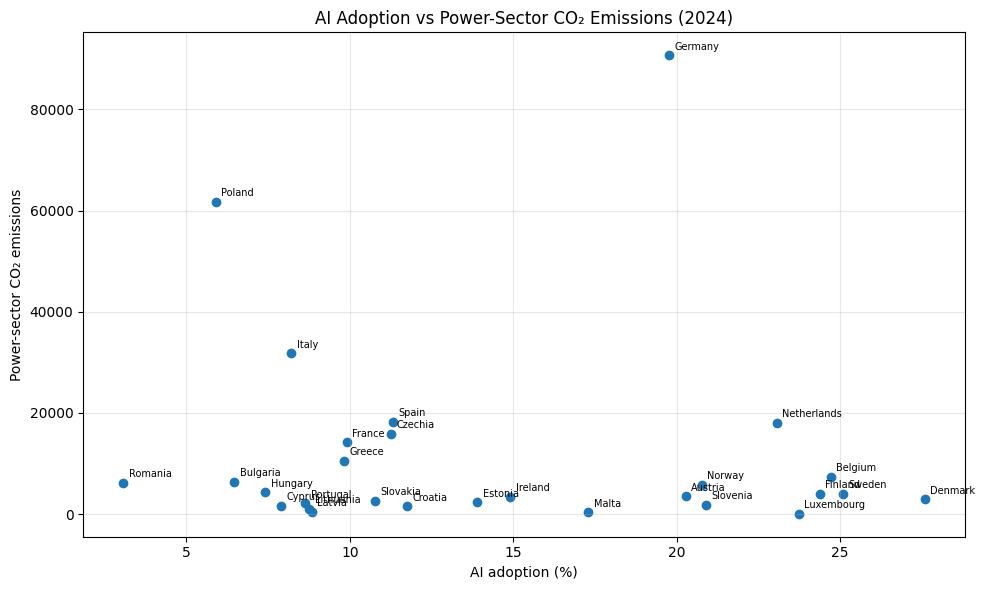

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    part4_latest["ai_adoption_pct"],
    part4_latest["emissions"]
)

for _, row in part4_latest.iterrows():
    plt.annotate(
        row["country_name"],
        (row["ai_adoption_pct"], row["emissions"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

plt.title(f"AI Adoption vs Power-Sector CO₂ Emissions ({latest_complete_year})")
plt.xlabel("AI adoption (%)")
plt.ylabel("Power-sector CO₂ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
This chart shows no clear overall relationship between AI adoption and power-sector CO₂ emissions. Countries with similar AI-adoption levels can have very different emissions profiles, while several high-adoption countries have relatively low emissions. The pattern suggests that national emissions are influenced far more by factors such as country size, electricity demand, industrial activity, and energy mix than by enterprise AI adoption alone.

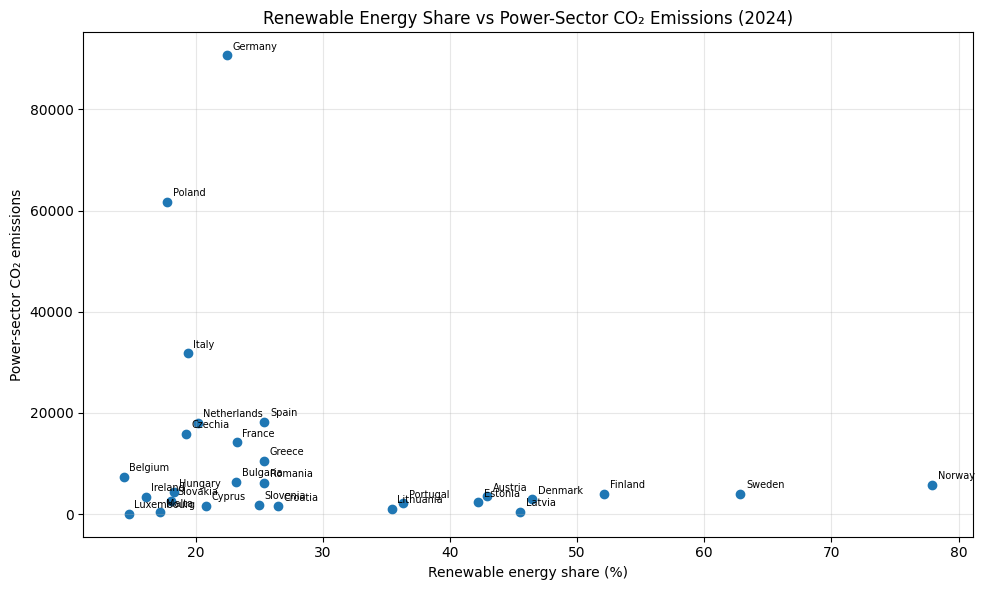

In [109]:
plt.figure(figsize=(10, 6))

plt.scatter(
    part4_latest["renewable_energy_share"],
    part4_latest["emissions"]
)

for _, row in part4_latest.iterrows():
    plt.annotate(
        row["country_name"],
        (row["renewable_energy_share"], row["emissions"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

plt.title(f"Renewable Energy Share vs Power-Sector CO₂ Emissions ({latest_complete_year})")
plt.xlabel("Renewable energy share (%)")
plt.ylabel("Power-sector CO₂ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Chart Summary
The chart shows a general tendency for countries with higher renewable-energy shares to have lower power-sector CO₂ emissions, but the relationship is not perfectly linear. Countries with lower renewable shares show a much wider spread of emissions, including several of the highest-emitting countries, while countries with stronger renewable shares are generally clustered at lower emission levels.

However, renewable share is not the only factor shaping emissions. National electricity demand, population size, industrial activity, and the scale of each country’s power system also matter, which helps explain why countries with similar renewable shares can still have very different emission levels. Overall, the pattern supports the idea that a stronger renewable-energy base can improve the conditions for more sustainable digital and AI growth, but it does not by itself determine a country’s emissions footprint.

In [84]:
ai_emissions_corr = part4_latest["ai_adoption_pct"].corr(
    part4_latest["emissions"]
)

renewable_emissions_corr = part4_latest["renewable_energy_share"].corr(
    part4_latest["emissions"]
)

print("Correlation: AI adoption vs emissions =", round(ai_emissions_corr, 3))
print("Correlation: Renewable energy vs emissions =", round(renewable_emissions_corr, 3))

Correlation: AI adoption vs emissions = -0.068
Correlation: Renewable energy vs emissions = -0.234


# Part 4 Summary
This analysis used the latest year with complete data across all three measures: 2024. After removing incomplete observations, the comparison included 28 Data Points.

Two country-level relationships were tested:

AI adoption vs. CO₂ emissions: correlation = −0.068

Renewable energy share vs. CO₂ emissions: correlation = −0.234

The AI-adoption correlation is extremely close to zero, meaning that countries with higher enterprise AI adoption did not consistently have either higher or lower power-sector CO₂ emissions in this dataset.

Renewable energy share showed a weak negative relationship with emissions. Countries with higher renewable-energy shares tended to have somewhat lower emissions, although the relationship was not strong.

These results do not prove that AI adoption causes emissions changes. National emissions are also heavily affected by country size, industrial activity, population, and electricity demand.

# 5   Sustainability Matrix

In [85]:
import numpy as np

# Create a separate dataframe for Part 5
matrix_df = part4_latest.copy()

# Calculate the middle value for each variable
ai_median = matrix_df["ai_adoption_pct"].median()
renewable_median = matrix_df["renewable_energy_share"].median()

print("AI adoption median:", round(ai_median, 2))
print("Renewable energy median:", round(renewable_median, 2))

# Create the four sustainability categories
conditions = [
    (matrix_df["ai_adoption_pct"] >= ai_median) &
    (matrix_df["renewable_energy_share"] >= renewable_median),

    (matrix_df["ai_adoption_pct"] >= ai_median) &
    (matrix_df["renewable_energy_share"] < renewable_median),

    (matrix_df["ai_adoption_pct"] < ai_median) &
    (matrix_df["renewable_energy_share"] >= renewable_median),

    (matrix_df["ai_adoption_pct"] < ai_median) &
    (matrix_df["renewable_energy_share"] < renewable_median)
]

categories = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

matrix_df["sustainability_category"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

# View country classifications
matrix_df[[
    "country_name",
    "ai_adoption_pct",
    "renewable_energy_share",
    "emissions",
    "sustainability_category"
]].sort_values("sustainability_category")

AI adoption median: 11.54
Renewable energy median: 24.12


,country_name,ai_adoption_pct,renewable_energy_share,emissions,sustainability_category
13,Hungary,7.41,18.264,4334.164835,Developing Transition
22,Poland,5.90,17.770,61778.186470,Developing Transition
15,Italy,8.20,19.385,31783.301550,Developing Transition
11,France,9.91,23.229,14176.046885,Developing Transition
27,Slovakia,10.78,18.092,2650.913265,Developing Transition
3,Cyprus,7.90,20.844,1609.332725,Developing Transition
2,Bulgaria,6.47,23.210,6388.932550,Developing Transition
4,Czechia,11.26,19.211,15863.437590,Developing Transition
5,Germany,19.75,22.474,90686.175580,Environmental Risk
1,Belgium,24.71,14.336,7349.221880,Environmental Risk


In [110]:
category_colors = {
    "Sustainable AI Leaders": "tab:blue",
    "Environmental Risk": "tab:red",
    "Green Potential": "tab:green",
    "Developing Transition": "tab:orange"
}

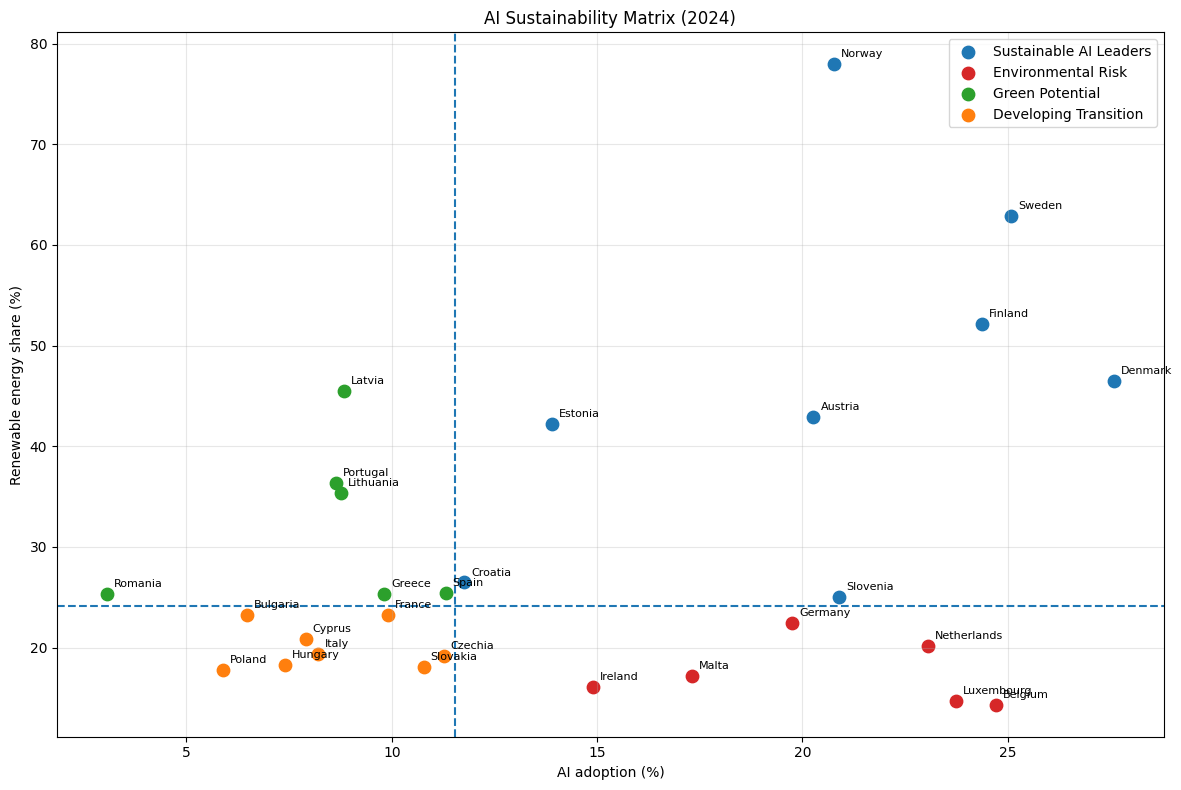

In [114]:
import matplotlib.pyplot as plt

category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

category_colors = {
    "Sustainable AI Leaders": "tab:blue",
    "Environmental Risk": "tab:red",
    "Green Potential": "tab:green",
    "Developing Transition": "tab:orange"
}

plt.figure(figsize=(12, 8))

# Plot one group at a time so the legend shows the categories
for category in category_order:
    subset = matrix_df[
        matrix_df["sustainability_category"] == category
    ]

    plt.scatter(
        subset["ai_adoption_pct"],
        subset["renewable_energy_share"],
        s=80,
        label=category,
        color=category_colors[category]
    )

# Add median lines to create the four quadrants
plt.axvline(ai_median, linestyle="--")
plt.axhline(renewable_median, linestyle="--")

# Add country labels
for _, row in matrix_df.iterrows():
    plt.annotate(
        row["country_name"],
        (row["ai_adoption_pct"], row["renewable_energy_share"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(f"AI Sustainability Matrix ({latest_complete_year})")
plt.xlabel("AI adoption (%)")
plt.ylabel("Renewable energy share (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
The matrix shows that Europe’s AI growth is occurring under very different energy conditions. Sustainable AI Leaders combine above-median enterprise AI adoption with above-median renewable-energy shares, suggesting they are comparatively well positioned to support further AI expansion with a stronger renewable base. In contrast, the Environmental Risk group has high AI adoption but lower renewable shares, meaning digital growth may place greater pressure on less renewable-backed energy systems.

The lower-adoption groups show two different paths: Green Potential countries have stronger renewable conditions but lower current AI adoption, while Developing Transition countries are below the median on both measures. Overall, the chart reinforces that high AI adoption is not automatically sustainable; the likely environmental impact of AI growth depends heavily on the renewable strength of each country’s energy system.

In [87]:
category_summary = (
    matrix_df
    .groupby("sustainability_category", as_index=False)
    .agg(
        number_of_countries=("geo", "count"),
        average_ai_adoption=("ai_adoption_pct", "mean"),
        average_renewable_share=("renewable_energy_share", "mean"),
        average_co2_emissions=("emissions", "mean")
    )
)

category_summary = category_summary.sort_values(
    "number_of_countries",
    ascending=False
)

print(category_summary)

  sustainability_category  number_of_countries  average_ai_adoption  \
0   Developing Transition                    8             8.478750   
3  Sustainable AI Leaders                    8            20.577500   
1      Environmental Risk                    6            20.575000   
2         Green Potential                    6             8.401667   

   average_renewable_share  average_co2_emissions  
0                20.000625           17323.039484  
3                47.003000            3278.560285  
1                17.501000           19997.374063  
2                32.236833            6461.648527  


In [90]:
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [91]:
from IPython.display import display

# Put categories in a logical presentation order
category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

heatmap_table = (
    category_summary
    .set_index("sustainability_category")
    .reindex(category_order)
)

# Display a colour-coded heatmap-style table
display(
    heatmap_table.style
    .format({
        "number_of_countries": "{:.0f}",
        "average_ai_adoption": "{:.2f}%",
        "average_renewable_share": "{:.2f}%",
        "average_co2_emissions": "{:,.0f}"
    })
    .background_gradient(
        cmap="Blues",
        subset=["number_of_countries", "average_ai_adoption"]
    )
    .background_gradient(
        cmap="YlGn",
        subset=["average_renewable_share"]
    )
    .background_gradient(
        cmap="RdYlGn_r",
        subset=["average_co2_emissions"]
    )
    .set_caption(
        "Sustainability Matrix Summary — greener CO₂ cells represent lower emissions"
    )
)

,number_of_countries,average_ai_adoption,average_renewable_share,average_co2_emissions
sustainability_category,,,,
Sustainable AI Leaders,8,20.58%,47.00%,"3,279"
Environmental Risk,6,20.57%,17.50%,"19,997"
Green Potential,6,8.40%,32.24%,"6,462"
Developing Transition,8,8.48%,20.00%,"17,323"


# Chart Summary
The heatmap shows that countries with similar AI-adoption levels can have very different environmental outcomes. In the AI-adoption column, both Sustainable AI Leaders and Environmental Risk countries are dark blue, showing similarly high adoption.

However, Sustainable AI Leaders are dark green in the renewable-energy column and green in the CO₂ column, indicating higher renewable-energy shares and lower emissions. Environmental Risk countries are pale yellow for renewables and red for CO₂ emissions, showing lower renewable-energy shares and the highest emissions.

Overall, the colour pattern suggests that high AI adoption is more sustainable when it is supported by cleaner electricity sources.

# Part 5 Summary
The sustainability matrix grouped the 28 countries using the median values for 2024:

Median AI adoption: 11.54%

Median renewable-energy share: 24.12%



The strongest contrast is between the first two categories:

Sustainable AI Leaders had average AI adoption of 20.58%, average renewable share of 47.00%, and average emissions of about 3,279.

Environmental Risk countries had nearly identical average AI adoption at 20.58%, but a much lower renewable share of 17.50% and substantially higher average emissions of about 19,997.

This suggests that high AI adoption alone does not determine sustainability. Countries appear better positioned to support AI growth sustainably when strong business AI adoption is combined with a higher renewable-energy share and relatively lower emissions.

The matrix is a comparative classification rather than a direct measure of AI’s environmental impact.

In [115]:
grouped_df


,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters
0,AL,2021,3.67,41.389,NaN,Albania,0
1,AL,2024,8.91,43.111,NaN,Albania,0
2,AL,2025,8.99,NaN,NaN,Albania,0
3,AT,2021,8.83,34.643,4289.129845,Austria,56
4,AT,2023,10.79,41.600,3595.912320,Austria,56
...,...,...,...,...,...,...,...
126,SK,2025,18.00,NaN,NaN,Slovakia,6
127,TR,2021,2.69,NaN,79097.198180,Türkiye,0
128,TR,2023,5.51,NaN,76613.496960,Türkiye,0
129,TR,2024,4.42,NaN,80135.840785,Türkiye,0


# 3B Datacenters

In [117]:
part3_dc = (
    grouped_df.loc[
        grouped_df["year"] == 2024,
        [
            "geo",
            "country_name",
            "datacenters",
            "renewable_energy_share"
        ]
    ]
    .dropna(subset=["datacenters", "renewable_energy_share"])
    .groupby(["geo", "country_name"], as_index=False)
    .agg(
        data_center_count=("datacenters", "first"),
        renewable_energy_share=("renewable_energy_share", "first")
    )
)

part3_dc.head()

,geo,country_name,data_center_count,renewable_energy_share
0,AL,Albania,0,43.111
1,AT,Austria,56,42.951
2,BA,Bosnia and Herzegovina,0,38.524
3,BE,Belgium,42,14.336
4,BG,Bulgaria,30,23.210


In [118]:
print("Countries included:", part3_dc["geo"].nunique())
print("Duplicate countries:", part3_dc["geo"].duplicated().sum())

Countries included: 32
Duplicate countries: 0


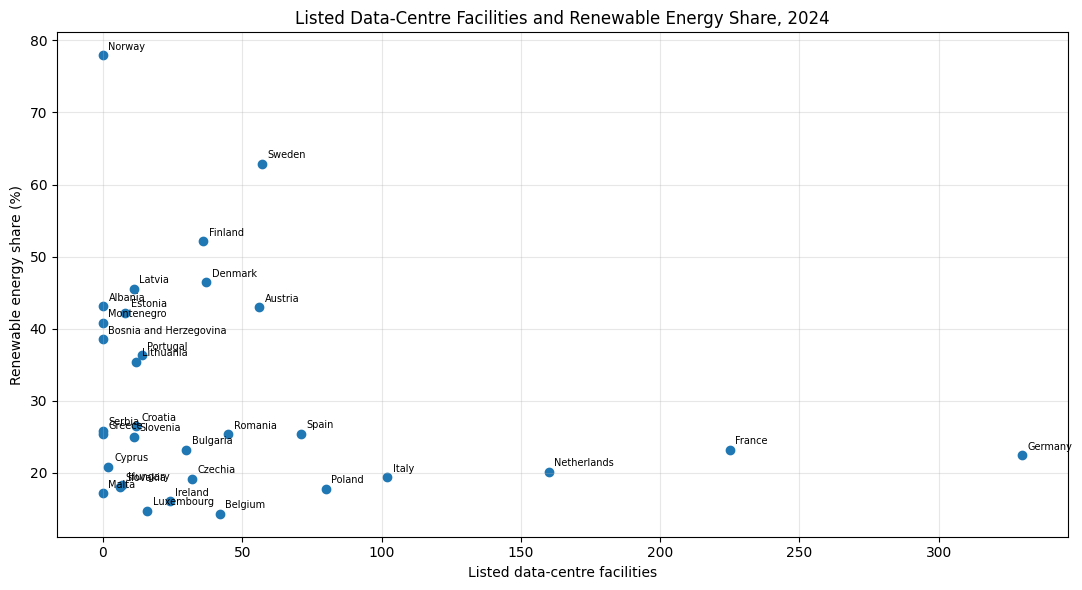

In [175]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.scatter(
    part3_dc["data_center_count"],
    part3_dc["renewable_energy_share"]
)

for _, row in part3_dc.iterrows():
    plt.annotate(
        row["country_name"],
        (row["data_center_count"], row["renewable_energy_share"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

plt.title("Listed Data-Centre Facilities and Renewable Energy Share, 2024")
plt.xlabel("Listed data-centre facilities")
plt.ylabel("Renewable energy share (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data_center_vs_renewable_energy_2024.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
dc_renewable_corr = part3_dc["data_center_count"].corr(
    part3_dc["renewable_energy_share"]
)

print(
    f"Data-centre count vs renewable-energy share correlation: "
    f"{dc_renewable_corr:.3f}"
)

Data-centre count vs renewable-energy share correlation: -0.203


# Summary
The chart shows no clear overall relationship between the number of listed data-centre facilities and renewable-energy share. Several countries with the largest data-centre presence have relatively low to moderate renewable shares, while some of the strongest renewable-energy systems have fewer listed facilities. This suggests that data-centre infrastructure is concentrated in countries with different energy profiles, and a larger facility footprint does not automatically mean it is supported by a cleaner energy base. Because the measure is a count of listed facilities rather than capacity or electricity use, it indicates infrastructure presence rather than direct environmental impact.

In [121]:
data_center_leaders = (
    part3_dc
    .sort_values("data_center_count", ascending=False)
    [[
        "country_name",
        "data_center_count",
        "renewable_energy_share"
    ]]
    .head(10)
    .reset_index(drop=True)
)

data_center_leaders.index += 1

data_center_leaders

,country_name,data_center_count,renewable_energy_share
1,Germany,330,22.474
2,France,225,23.229
3,Netherlands,160,20.180
4,Italy,102,19.385
5,Poland,80,17.770
6,Spain,71,25.417
7,Sweden,57,62.846
8,Austria,56,42.951
9,Romania,45,25.378
10,Belgium,42,14.336


# 3B Summary:
The 3B analysis shows that a larger number of listed data-centre facilities does not automatically correspond to a stronger renewable-energy base. Data-centre infrastructure is spread across countries with very different energy profiles: some appear relatively well positioned to support digital growth with higher renewable shares, while others combine substantial infrastructure with less renewable-backed energy systems. This suggests that the sustainability of expanding digital infrastructure depends not only on where facilities are concentrated, but also on how quickly national energy systems transition toward renewables. Because the data measures listed facilities rather than capacity or electricity use, the findings describe infrastructure presence rather than direct environmental impact.

# 4B focus on Datacenters

In [122]:
part4_dc = (
    grouped_df.loc[
        grouped_df["year"] == 2024,
        [
            "geo",
            "country_name",
            "datacenters",
            "emissions"
        ]
    ]
    .dropna(subset=["datacenters", "emissions"])
    .copy()
)

part4_dc.head()

,geo,country_name,datacenters,emissions
5,AT,Austria,56,3577.318745
13,BE,Belgium,42,7349.221880
17,BG,Bulgaria,30,6388.932550
21,CY,Cyprus,2,1609.332725
25,CZ,Czechia,32,15863.437590


In [123]:
print("Countries:", part4_dc["geo"].nunique())
print("Duplicate country rows:", part4_dc["geo"].duplicated().sum())

Countries: 29
Duplicate country rows: 0


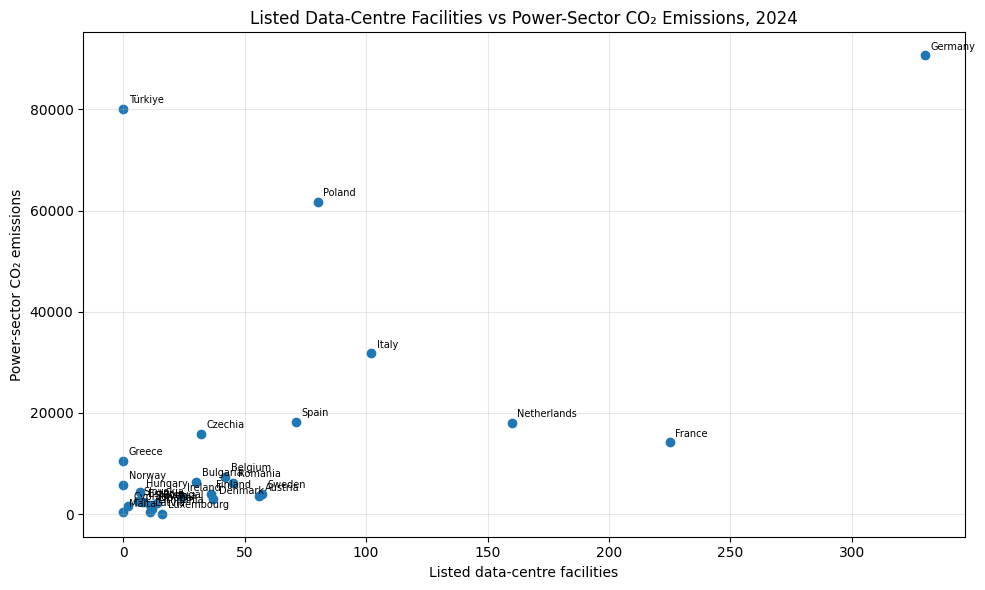

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    part4_dc["datacenters"],
    part4_dc["emissions"]
)

for _, row in part4_dc.iterrows():
    plt.annotate(
        row["country_name"],
        (row["datacenters"], row["emissions"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

plt.title("Listed Data-Centre Facilities vs Power-Sector CO₂ Emissions, 2024")
plt.xlabel("Listed data-centre facilities")
plt.ylabel("Power-sector CO₂ emissions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data_center_vs_emissions_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary
The chart shows a broad positive relationship between listed data-centre facilities and power-sector CO₂ emissions: countries with larger data-centre footprints tend to appear among the higher-emitting countries. However, this pattern is strongly influenced by large national economies and electricity systems, rather than showing that data centres themselves are the direct cause of emissions.

Several countries with relatively few listed facilities still have high emissions, while others with substantial infrastructure have more moderate emissions. This suggests that digital infrastructure is only one part of the picture; country size, industrial activity, electricity demand, and the national energy mix are all likely to shape total power-sector emissions.

In [125]:
dc_emissions_corr = part4_dc["datacenters"].corr(
    part4_dc["emissions"]
)

print(
    f"Data-centre count vs power-sector CO₂ emissions correlation: "
    f"{dc_emissions_corr:.3f}"
)

Data-centre count vs power-sector CO₂ emissions correlation: 0.574


In [126]:
data_center_emissions_table = (
    part4_dc
    .sort_values("datacenters", ascending=False)
    [["country_name", "datacenters", "emissions"]]
    .head(10)
    .reset_index(drop=True)
)

data_center_emissions_table.index += 1

data_center_emissions_table

,country_name,datacenters,emissions
1,Germany,330,90686.175580
2,France,225,14176.046885
3,Netherlands,160,18021.063060
4,Italy,102,31783.301550
5,Poland,80,61778.186470
6,Spain,71,18262.404160
7,Sweden,57,3999.075080
8,Austria,56,3577.318745
9,Romania,45,6165.148990
10,Belgium,42,7349.221880


# Summary
The data-centre comparison does not show a simple one-to-one relationship between the number of listed facilities and power-sector CO₂ emissions. Countries with a larger data-centre presence can have very different emissions profiles, suggesting that national emissions are shaped more strongly by factors such as country size, electricity demand, industry, and energy mix. Listed facility count is therefore a useful measure of infrastructure presence, but it does not measure data-centre capacity, electricity use, or AI-specific environmental impact.

# 5B using datacenter values

In [138]:
import numpy as np
import matplotlib.pyplot as plt

matrix_dc = part3_dc.copy()

dc_median = matrix_dc["data_center_count"].median()
renewable_median = matrix_dc["renewable_energy_share"].median()

print(f"Median data-centre count: {dc_median}")
print(f"Median renewable-energy share: {renewable_median:.2f}%")

Median data-centre count: 15.0
Median renewable-energy share: 25.37%


In [145]:
# Attach the existing AI sustainability category to the data-centre dataframe
dc_by_ai_category = part3_dc.merge(
    matrix_df[["geo", "sustainability_category"]].drop_duplicates("geo"),
    on="geo",
    how="inner",
    validate="one_to_one"
)

category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

category_colors = {
    "Sustainable AI Leaders": "tab:blue",
    "Environmental Risk": "tab:red",
    "Green Potential": "tab:green",
    "Developing Transition": "tab:orange"
}

In [146]:
dc_by_ai_category[
    [
        "country_name",
        "data_center_count",
        "renewable_energy_share",
        "sustainability_category"
    ]
].sort_values(
    ["sustainability_category", "data_center_count"],
    ascending=[True, False]
)


,country_name,data_center_count,renewable_energy_share,sustainability_category
11,France,225,23.229,Developing Transition
15,Italy,102,19.385,Developing Transition
22,Poland,80,17.770,Developing Transition
4,Czechia,32,19.211,Developing Transition
2,Bulgaria,30,23.210,Developing Transition
13,Hungary,7,18.264,Developing Transition
27,Slovakia,6,18.092,Developing Transition
3,Cyprus,2,20.844,Developing Transition
5,Germany,330,22.474,Environmental Risk
20,Netherlands,160,20.180,Environmental Risk


In [156]:
dc_category_data = dc_by_ai_category.merge(
    matrix_df[["geo", "emissions"]].drop_duplicates("geo"),
    on="geo",
    how="left",
    validate="one_to_one"
)

dc_category_data.head()

,geo,country_name,data_center_count,renewable_energy_share,sustainability_category,emissions
0,AT,Austria,56,42.951,Sustainable AI Leaders,3577.318745
1,BE,Belgium,42,14.336,Environmental Risk,7349.221880
2,BG,Bulgaria,30,23.210,Developing Transition,6388.932550
3,CY,Cyprus,2,20.844,Developing Transition,1609.332725
4,CZ,Czechia,32,19.211,Developing Transition,15863.437590


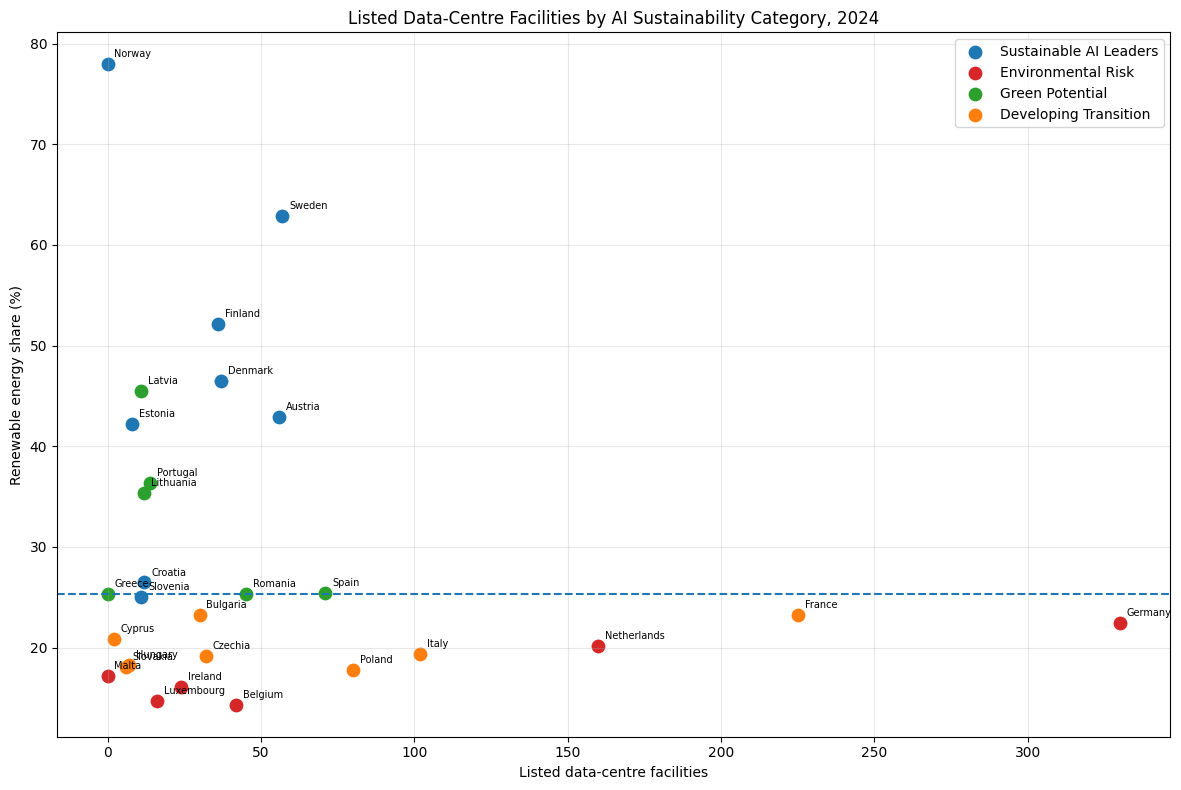

In [177]:
import matplotlib.pyplot as plt

category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

category_colors = {
    "Sustainable AI Leaders": "tab:blue",
    "Environmental Risk": "tab:red",
    "Green Potential": "tab:green",
    "Developing Transition": "tab:orange"
}

plt.figure(figsize=(12, 8))

for category in category_order:
    subset = dc_by_ai_category[
        dc_by_ai_category["sustainability_category"] == category
    ]

    plt.scatter(
        subset["data_center_count"],
        subset["renewable_energy_share"],
        s=80,
        label=category,
        color=category_colors[category]
    )

# This remains relevant because renewable share is part of the original AI categories
plt.axhline(renewable_median, linestyle="--")

for _, row in dc_by_ai_category.iterrows():
    plt.annotate(
        row["country_name"],
        (row["data_center_count"], row["renewable_energy_share"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7
    )

plt.title("Listed Data-Centre Facilities by AI Sustainability Category, 2024")
plt.xlabel("Listed data-centre facilities")
plt.ylabel("Renewable energy share (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data_center_by_ai_category_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary
This chart adds a data-centre infrastructure lens to the original AI sustainability categories. Sustainable AI Leaders generally combine strong renewable-energy shares with modest-to-medium listed data-centre footprints, suggesting that favourable energy conditions can coexist with active AI adoption without necessarily requiring the largest facility concentration. In contrast, Environmental Risk countries remain below the renewable-energy benchmark and include some of the largest listed data-centre footprints, reinforcing the concern that infrastructure growth may create greater pressure where the energy system is less renewable-backed.

Green Potential countries tend to have stronger renewable conditions but smaller current data-centre footprints, which may position them for cleaner future digital expansion. Developing Transition countries generally combine lower renewable shares with more limited infrastructure, indicating that both digital development and energy transition may still need to progress together. Importantly, the colours come from the original AI-adoption and renewable-energy categories—not from data-centre counts—so the chart shows how current infrastructure is distributed across those existing sustainability profiles.

In [159]:
dc_category_summary = (
    dc_category_data
    .groupby("sustainability_category", as_index=False)
    .agg(
        number_of_countries=("geo", "count"),
        average_data_center_count=("data_center_count", "mean"),
        average_renewable_share=("renewable_energy_share", "mean"),
        average_co2_emissions=("emissions", "mean")
    )
)

category_order = [
    "Sustainable AI Leaders",
    "Environmental Risk",
    "Green Potential",
    "Developing Transition"
]

dc_category_summary["sustainability_category"] = pd.Categorical(
    dc_category_summary["sustainability_category"],
    categories=category_order,
    ordered=True
)

dc_category_summary = (
    dc_category_summary
    .sort_values("sustainability_category")
    .set_index("sustainability_category")
)

dc_category_summary

,number_of_countries,average_data_center_count,average_renewable_share,average_co2_emissions
sustainability_category,,,,
Sustainable AI Leaders,8,27.125000,47.003000,3278.560285
Environmental Risk,6,95.333333,17.501000,19997.374063
Green Potential,6,25.500000,32.236833,6461.648527
Developing Transition,8,60.500000,20.000625,17323.039484


In [188]:
styled_dc_summary = (
    dc_category_summary.style
    .format({
        "number_of_countries": "{:.0f}",
        "average_data_center_count": "{:.1f}",
        "average_renewable_share": "{:.2f}%",
        "average_co2_emissions": "{:,.0f}"
    })
    .background_gradient(
        cmap="Blues",
        subset=["number_of_countries", "average_data_center_count"]
    )
    .background_gradient(
        cmap="YlGn",
        subset=["average_renewable_share"]
    )
    .background_gradient(
        cmap="YlOrRd",
        subset=["average_co2_emissions"]
    )
)

styled_dc_summary


,number_of_countries,average_data_center_count,average_renewable_share,average_co2_emissions
sustainability_category,,,,
Sustainable AI Leaders,8,27.1,47.00%,"3,279"
Environmental Risk,6,95.3,17.50%,"19,997"
Green Potential,6,25.5,32.24%,"6,462"
Developing Transition,8,60.5,20.00%,"17,323"


# Chart summary
The table highlights a clear sustainability divide between the categories. Environmental Risk countries have the largest average listed data-centre presence while also showing the lowest renewable-energy share and highest average CO₂ emissions, making this group the clearest potential pressure point as digital infrastructure expands. In contrast, Sustainable AI Leaders combine a meaningful data-centre presence with the strongest renewable-energy base and lowest average emissions, suggesting comparatively more favourable conditions for supporting AI and digital growth.

Green Potential countries currently have relatively limited listed infrastructure but a stronger renewable base, which may give them a better foundation for cleaner future expansion. Meanwhile, Developing Transition countries have a larger average data-centre presence than Green Potential but weaker renewable shares and relatively high emissions, indicating that energy-system improvements may need to keep pace with infrastructure growth. These are country-level patterns rather than evidence of direct data-centre emissions, since facility counts do not measure capacity or electricity use.

# 5B Summary 
The 5B analysis reinforces the original AI sustainability story by adding a data-centre infrastructure lens. Countries already classified as Environmental Risk tend to combine the largest listed data-centre presence with weaker renewable-energy shares, suggesting that digital infrastructure growth may place greater pressure on less renewable-backed energy systems. Sustainable AI Leaders show a more balanced position, combining a meaningful infrastructure footprint with stronger renewable-energy conditions. Meanwhile, Green Potential countries appear to have a cleaner foundation for future expansion, while Developing Transition countries may need energy-system improvements to keep pace with their existing infrastructure. These results describe country-level patterns only: listed facilities are not a measure of data-centre capacity, electricity use, or direct emissions.


# 6B datacenters

In [162]:
correlation_columns = [
    "ai_adoption_pct",
    "datacenters",
    "renewable_energy_share",
    "emissions"
]

country_value_check = (
    grouped_df.loc[
        grouped_df["year"] == 2024,
        ["geo"] + correlation_columns
    ]
    .groupby("geo")[correlation_columns]
    .nunique()
)

country_value_check[
    country_value_check.gt(1).any(axis=1)
]

,ai_adoption_pct,datacenters,renewable_energy_share,emissions
geo,,,,


In [163]:
correlation_df = (
    grouped_df.loc[
        grouped_df["year"] == 2024,
        [
            "geo",
            "country_name",
            "ai_adoption_pct",
            "datacenters",
            "renewable_energy_share",
            "emissions"
        ]
    ]
    .dropna()
    .drop_duplicates(subset="geo")
    .rename(columns={
        "datacenters": "listed_data_center_facilities"
    })
)

correlation_df.head()

,geo,country_name,ai_adoption_pct,listed_data_center_facilities,renewable_energy_share,emissions
5,AT,Austria,20.27,56,42.951,3577.318745
13,BE,Belgium,24.71,42,14.336,7349.221880
17,BG,Bulgaria,6.47,30,23.210,6388.932550
21,CY,Cyprus,7.90,2,20.844,1609.332725
25,CZ,Czechia,11.26,32,19.211,15863.437590


In [164]:
correlation_metrics = correlation_df[
    [
        "ai_adoption_pct",
        "listed_data_center_facilities",
        "renewable_energy_share",
        "emissions"
    ]
].rename(columns={
    "ai_adoption_pct": "AI adoption (%)",
    "listed_data_center_facilities": "Listed data-centre facilities",
    "renewable_energy_share": "Renewable energy share (%)",
    "emissions": "CO₂ emissions"
})

correlation_matrix = correlation_metrics.corr(method="pearson")

correlation_matrix.round(2)

,AI adoption (%),Listed data-centre facilities,Renewable energy share (%),CO₂ emissions
AI adoption (%),1.00,0.12,0.35,-0.07
Listed data-centre facilities,0.12,1.00,-0.17,0.77
Renewable energy share (%),0.35,-0.17,1.00,-0.23
CO₂ emissions,-0.07,0.77,-0.23,1.00


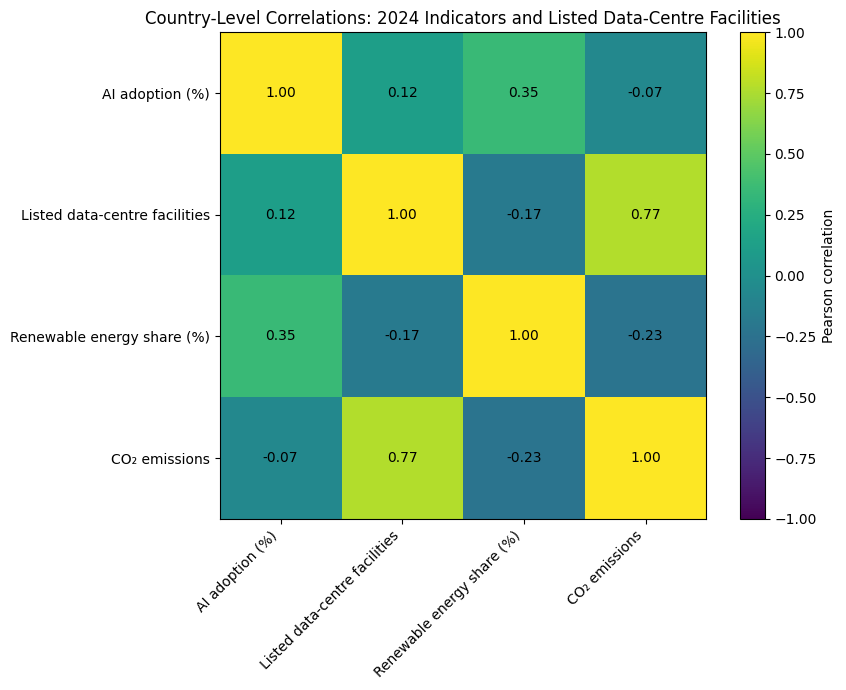

In [189]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(correlation_matrix.index)

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        ax.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")

plt.title(
    "Country-Level Correlations: 2024 Indicators and Listed Data-Centre Facilities"
)
plt.tight_layout()
plt.savefig("correlation_matrix_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap Summary
The heatmap shows that listed data-centre facilities have the strongest relationship with national CO₂ emissions in this dataset, with a strong positive correlation. This suggests that countries with a larger digital-infrastructure footprint also tend to report higher total power-sector emissions, although this pattern may largely reflect wider factors such as country size, electricity demand, industrial activity, and a country’s role as a digital hub.

AI adoption has only a very weak relationship with emissions, indicating that the share of enterprises using AI does not by itself explain national CO₂ levels. Renewable-energy share shows a modest negative relationship with emissions, which is directionally consistent with cleaner energy systems being associated with lower emissions, but the relationship is not strong. Overall, the results suggest that infrastructure presence is more closely associated with emissions than enterprise AI adoption, while the environmental sustainability of digital growth still depends heavily on each country’s energy mix.

# 6B Summary
Overall, the 6B correlation analysis suggests that the environmental pattern around digital growth is more closely linked to data-centre infrastructure presence than to enterprise AI adoption alone. Listed data-centre facilities show the strongest positive association with national CO₂ emissions, while AI adoption has little apparent relationship with emissions. Renewable-energy share has a modest negative relationship with emissions, reinforcing the idea that cleaner energy systems may help reduce the environmental pressure associated with digital infrastructure. These findings do not show that data centres or AI directly cause emissions; instead, they indicate that country size, electricity demand, industrial activity, digital-hub status, and especially the national energy mix are important when assessing whether AI growth is environmentally sustainable.bb

In [166]:
common_years = [2021, 2023, 2024]

average_source = (
    grouped_df[
        grouped_df["year"].isin(common_years)
    ]
    .dropna(subset=[
        "ai_adoption_pct",
        "renewable_energy_share",
        "emissions",
        "datacenters"
    ])
    .copy()
)

# Check that each country has all three usable years
year_check = (
    average_source
    .groupby("geo")["year"]
    .nunique()
    .sort_values()
)

year_check[year_check < len(common_years)]

Series([], Name: year, dtype: int64)

In [167]:
country_average_df = (
    average_source
    .groupby(["geo", "country_name"], as_index=False)
    .agg(
        average_ai_adoption=("ai_adoption_pct", "mean"),
        average_renewable_share=("renewable_energy_share", "mean"),
        average_co2_emissions=("emissions", "mean"),
        listed_data_center_facilities=("datacenters", "first")
    )
)

country_average_df.head()

,geo,country_name,average_ai_adoption,average_renewable_share,average_co2_emissions,listed_data_center_facilities
0,AT,Austria,13.296667,39.731333,3820.786970,56
1,BE,Belgium,16.280000,14.008667,8045.941237,42
2,BG,Bulgaria,4.460000,21.918333,8410.755687,30
3,CY,Cyprus,5.053333,20.042000,1558.733843,2
4,CZ,Czechia,7.206667,18.460000,18009.016025,32


In [168]:
average_corr = country_average_df[
    [
        "average_ai_adoption",
        "listed_data_center_facilities",
        "average_renewable_share",
        "average_co2_emissions"
    ]
].rename(columns={
    "average_ai_adoption": "Average AI adoption (%)",
    "listed_data_center_facilities": "Listed data-centre facilities",
    "average_renewable_share": "Average renewable energy share (%)",
    "average_co2_emissions": "Average CO₂ emissions"
}).corr()

average_corr.round(2)

,Average AI adoption (%),Listed data-centre facilities,Average renewable energy share (%),Average CO₂ emissions
Average AI adoption (%),1.00,0.14,0.28,-0.06
Listed data-centre facilities,0.14,1.00,-0.18,0.78
Average renewable energy share (%),0.28,-0.18,1.00,-0.24
Average CO₂ emissions,-0.06,0.78,-0.24,1.00


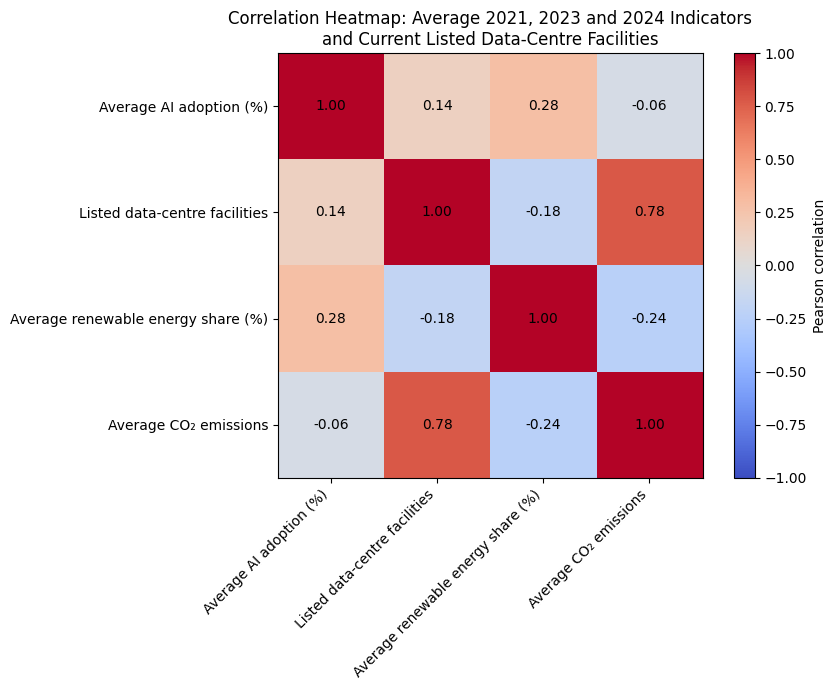

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    average_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(average_corr.columns)),
    average_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(average_corr.index)),
    average_corr.index
)

for i in range(len(average_corr.index)):
    for j in range(len(average_corr.columns)):
        plt.text(
            j,
            i,
            f"{average_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(label="Pearson correlation")

plt.title(
    "Correlation Heatmap: Average 2021, 2023 and 2024 Indicators\n"
    "and Current Listed Data-Centre Facilities"
)

plt.tight_layout()
plt.savefig("correlation_matrix_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart Summary
The heatmap shows that current listed data-centre facilities have the strongest relationship with average CO₂ emissions across the countries in this dataset. This suggests that countries with a larger digital-infrastructure footprint also tend to have higher overall emissions, although this likely reflects broader national factors such as country size, electricity demand, industrial activity, and digital-hub status rather than data centres alone.

In contrast, average AI adoption has little relationship with either emissions or data-centre counts. Renewable-energy share has a weak negative relationship with both data-centre facilities and emissions, suggesting that stronger renewable systems may be associated with somewhat lower environmental pressure, but this pattern is not strong enough to be predictive on its own.

# 6B Summary
The 6B analysis indicates that the sustainability implications of AI growth appear to be more closely connected to underlying digital infrastructure and national energy conditions than to enterprise AI adoption alone. AI adoption itself does not show a meaningful relationship with emissions, whereas countries with more listed data-centre facilities tend to have substantially higher average CO₂ emissions. At the same time, renewable-energy share shows a modest inverse relationship with emissions, supporting the idea that cleaner energy systems can help reduce the environmental pressure associated with digital growth.

These results show association rather than causation. Listed facilities do not measure data-centre capacity, electricity use, or AI-specific emissions, and the emissions comparison should remain conditional on confirming that the source uses a consistent unit across all countries and years.

In [191]:
# 1. Exact duplicate rows across every column
print("Exact duplicate rows:", grouped_df.duplicated().sum())

Exact duplicate rows: 0


In [192]:
# 2. Duplicate country-year rows
duplicate_country_years = grouped_df[
    grouped_df.duplicated(subset=["geo", "year"], keep=False)
].sort_values(["geo", "year"])

print("Duplicate country-year rows:", len(duplicate_country_years))

duplicate_country_years

Duplicate country-year rows: 0


,geo,year,ai_adoption_pct,renewable_energy_share,emissions,country_name,datacenters
